<a href="https://colab.research.google.com/github/VainaviS/EndoNet/blob/main/notebooks/MaskRCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install libraries
!pip install torch torchvision
!pip install opencv-python matplotlib
!pip install pycocotools
!pip install 'git+https://github.com/facebookresearch/detectron2.git'

  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-468y00ez
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-468y00ez
  Resolved https://github.com/facebookresearch/detectron2.git to commit fd27788985af0f4ca800bca563acdb700bb890e2
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 33.6 MB/s eta 0:00:00
  Created wheel for detectron2: filename=detectron2-0.6-cp312-cp312-linux_x86_64.whl size=7111532 sha2

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Glenda_v1.5_classes.zip to Glenda_v1.5_classes.zip


In [3]:
!unzip Glenda_v1.5_classes.zip -d /content/glenda

Archive:  Glenda_v1.5_classes.zip
   creating: /content/glenda/Glenda_v1.5_classes/
   creating: /content/glenda/Glenda_v1.5_classes/annots/
  inflating: /content/glenda/Glenda_v1.5_classes/annots/c_100_v_(video_3062.mp4)_f_1458.png  
  inflating: /content/glenda/Glenda_v1.5_classes/annots/c_102_v_(video_3119.mp4)_f_1311.png  
  inflating: /content/glenda/Glenda_v1.5_classes/annots/c_102_v_(video_3119.mp4)_f_185.png  
  inflating: /content/glenda/Glenda_v1.5_classes/annots/c_102_v_(video_3124.mp4)_f_97.png  
  inflating: /content/glenda/Glenda_v1.5_classes/annots/c_102_v_(video_3130.mp4)_f_0.png  
  inflating: /content/glenda/Glenda_v1.5_classes/annots/c_105_v_(video_3214.mp4)_f_2954.png  
  inflating: /content/glenda/Glenda_v1.5_classes/annots/c_108_v_(video_3312.mp4)_f_619.png  
  inflating: /content/glenda/Glenda_v1.5_classes/annots/c_10_v_(video_182.mp4)_f_494.png  
  inflating: /content/glenda/Glenda_v1.5_classes/annots/c_10_v_(video_184.mp4)_f_22.png  
  inflating: /content/glend

In [4]:
!ls /content/glenda

Glenda_v1.5_classes


In [6]:
random.seed(42)

train_split = 0.7
val_split = 0.2

random.shuffle(images)

train_end = int(len(images)*train_split)
val_end = int(len(images)*(train_split+val_split))

train_images = images[:train_end]
val_images = images[train_end:val_end]
test_images = images[val_end:]

print(len(train_images), len(val_images), len(test_images))

261 74 38


In [8]:
base = "/content/glenda_split"

dirs = [
    "train/images",
    "train/masks",
    "val/images",
    "val/masks",
    "test/images",
    "test/masks"
]

for d in dirs:
    os.makedirs(os.path.join(base,d), exist_ok=True)

def copy_files(image_list, split):

    for img in image_list:

        img_src = os.path.join(images_path, img)

        # convert image name to mask name
        mask_name = img.replace(".jpg", ".png")
        mask_src = os.path.join(annots_path, mask_name)

        if not os.path.exists(mask_src):
            print("Missing mask for:", img)
            continue

        shutil.copy(img_src, f"{base}/{split}/images/")
        shutil.copy(mask_src, f"{base}/{split}/masks/")

copy_files(train_images,"train")
copy_files(val_images,"val")
copy_files(test_images,"test")

In [10]:
!ls /content/glenda_split/train/images | wc -l
!ls /content/glenda_split/val/images | wc -l
!ls /content/glenda_split/test/images | wc -l

261
74
38


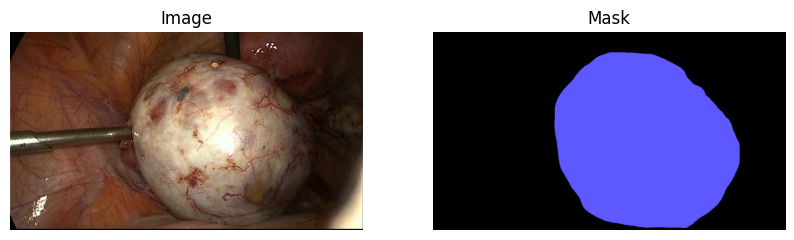

In [13]:
sample = train_images[0]

img = cv2.imread(f"{base}/train/images/{sample}")
mask = cv2.imread(f"{base}/train/masks/{sample}")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Mask")
plt.imshow(mask)
plt.axis("off")

plt.show()

In [14]:
!pip install imantics

  Preparing metadata (setup.py) ... done
  Created wheel for imantics: filename=imantics-0.1.12-py3-none-any.whl size=16009 sha256=9fd73b2893b185aa4deddf69e4bbbbe7d6fecaa8cb89114dfdc3861bcc5771ce
  Stored in directory: /root/.cache/pip/wheels/40/e1/8d/fd1fa8f30722831661afc8e6efcda609c72d1b73e11f4d49b7
Successfully built imantics


In [23]:
from imantics import Mask
import json

def create_coco_json(split):

    images = []
    annotations = []
    ann_id = 0

    img_files = os.listdir(f"{base}/{split}/images")

    for idx, img_name in enumerate(img_files):

        img_path = f"{base}/{split}/images/{img_name}"
        mask_name = img_name.replace(".jpg",".png")
        mask_path = f"{base}/{split}/masks/{mask_name}"


        img = cv2.imread(img_path)
        h,w,_ = img.shape

        images.append({
            "id": idx,
            "file_name": img_name,
            "height": h,
            "width": w
        })

        mask_img = cv2.imread(mask_path)

        gray = cv2.cvtColor(mask_img, cv2.COLOR_BGR2GRAY)

        ret,thresh = cv2.threshold(gray,1,255,0)

        contours,_ = cv2.findContours(thresh,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

        for c in contours:

            segmentation = c.flatten().tolist()

            x,y,w_box,h_box = cv2.boundingRect(c)

            annotations.append({
                "id": ann_id,
                "image_id": idx,
                "category_id": 1,
                "bbox":[x,y,w_box,h_box],
                "segmentation":[segmentation],
                "area":w_box*h_box,
                "iscrowd":0
            })

            ann_id+=1

    coco = {
        "images":images,
        "annotations":annotations,
        "categories":[
            {"id":1,"name":"lesion"}
        ]
    }

    with open(f"/content/{split}.json","w") as f:
        json.dump(coco,f)


In [34]:
def copy_files(image_list, split):

    for img in image_list:

        img_src = os.path.join(images_path, img)

        mask_name = img.replace(".jpg", ".png")
        mask_src = os.path.join(annots_path, mask_name)

        shutil.copy(img_src, f"{base}/{split}/images/")
        shutil.copy(mask_src, f"{base}/{split}/masks/")

In [35]:
create_coco_json("train")
create_coco_json("val")

In [36]:
from detectron2.data.datasets import register_coco_instances
from detectron2.data import MetadataCatalog

register_coco_instances(
    "glenda_train",
    {},
    "/content/data/train/annotations.json",
    "/content/data/train/images"
)

register_coco_instances(
    "glenda_val",
    {},
    "/content/data/val/annotations.json",
    "/content/data/val/images"
)

MetadataCatalog.get("glenda_train").thing_classes = [
    "Peritoneum",
    "Ovary",
    "TIE",
    "Uterus"
]

AssertionError: Attribute 'json_file' in the metadata of 'glenda_train' cannot be set to a different value!
/content/train.json != /content/data/train/annotations.json

In [26]:
from detectron2.config import get_cfg
from detectron2 import model_zoo

cfg = get_cfg()

cfg.merge_from_file(
model_zoo.get_config_file(
"COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))

cfg.DATASETS.TRAIN=("glenda_train",)
cfg.DATASETS.TEST=("glenda_val",)

cfg.DATALOADER.NUM_WORKERS=2

cfg.MODEL.WEIGHTS=model_zoo.get_checkpoint_url(
"COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")

cfg.SOLVER.IMS_PER_BATCH=2
cfg.SOLVER.BASE_LR=0.00025
cfg.SOLVER.MAX_ITER=3000

cfg.MODEL.ROI_HEADS.NUM_CLASSES=1

In [27]:
from detectron2.engine import DefaultTrainer

trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

[03/15 13:34:29 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

model_final_f10217.pkl: 178MB [00:00, 264MB/s]                           
roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}
roi_heads.mask_head.predictor.{bias, weight}


[03/15 13:34:30 d2.engine.train_loop]: Starting training from iteration 0


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0315 13:34:33.519000 1698 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


[03/15 13:34:44 d2.utils.events]:  eta: 0:26:45  iter: 19  total_loss: 1.493  loss_cls: 0.5696  loss_box_reg: 0.04765  loss_mask: 0.6957  loss_rpn_cls: 0.1284  loss_rpn_loc: 0.01544    time: 0.5316  last_time: 0.4880  data_time: 0.0139  last_data_time: 0.0071   lr: 4.9953e-06  max_mem: 2582M
[03/15 13:35:02 d2.utils.events]:  eta: 0:26:47  iter: 39  total_loss: 1.386  loss_cls: 0.4928  loss_box_reg: 0.06714  loss_mask: 0.693  loss_rpn_cls: 0.111  loss_rpn_loc: 0.02065    time: 0.5398  last_time: 0.5704  data_time: 0.0073  last_data_time: 0.0096   lr: 9.9902e-06  max_mem: 2582M
[03/15 13:35:13 d2.utils.events]:  eta: 0:26:55  iter: 59  total_loss: 1.214  loss_cls: 0.3637  loss_box_reg: 0.04792  loss_mask: 0.692  loss_rpn_cls: 0.1143  loss_rpn_loc: 0.0115    time: 0.5489  last_time: 0.5889  data_time: 0.0093  last_data_time: 0.0108   lr: 1.4985e-05  max_mem: 2583M
[03/15 13:35:24 d2.utils.events]:  eta: 0:26:54  iter: 79  total_loss: 1.112  loss_cls: 0.2498  loss_box_reg: 0.06984  loss_m

In [28]:
from detectron2.engine import DefaultPredictor

predictor = DefaultPredictor(cfg)

img = cv2.imread(f"{base}/test/images/{test_images[0]}")

outputs = predictor(img)
print(outputs)

[03/15 14:12:14 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from https://dl.fbaipublicfiles.com/detectron2/COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x/137849600/model_final_f10217.pkl ...


roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}
roi_heads.mask_head.predictor.{bias, weight}


{'instances': Instances(num_instances=100, image_height=360, image_width=640, fields=[pred_boxes: Boxes(tensor([[5.0483e+00, 9.4016e+01, 2.1512e+02, 1.2354e+02],
        [2.3926e+02, 1.9866e+02, 3.1201e+02, 2.6880e+02],
        [4.9383e+02, 3.4515e+02, 5.9142e+02, 3.5770e+02],
        [1.1100e+02, 6.0087e+00, 1.5958e+02, 1.0148e+02],
        [3.3271e+02, 1.9203e+02, 3.8665e+02, 2.0563e+02],
        [2.7861e+02, 2.6985e+02, 3.1230e+02, 2.7876e+02],
        [1.4183e+02, 6.2535e-01, 1.6070e+02, 1.1836e+01],
        [4.0791e+02, 3.4721e+02, 4.2710e+02, 3.5684e+02],
        [3.2242e+02, 1.9511e+02, 3.5203e+02, 2.1928e+02],
        [5.1791e+01, 8.2829e+01, 1.9424e+02, 2.8542e+02],
        [3.8815e+02, 3.4228e+02, 4.4718e+02, 3.5786e+02],
        [1.8738e+00, 2.0081e+02, 3.7370e+01, 2.3265e+02],
        [4.0608e+02, 3.4127e+02, 4.6907e+02, 3.5765e+02],
        [3.2652e+02, 1.8903e+02, 3.5481e+02, 2.0981e+02],
        [5.8517e+02, 3.4523e+02, 6.1895e+02, 3.5637e+02],
        [3.3071e+02, 1.874

In [29]:
from detectron2.engine import DefaultPredictor

cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5

predictor = DefaultPredictor(cfg)

[03/15 14:13:01 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./output/model_final.pth ...


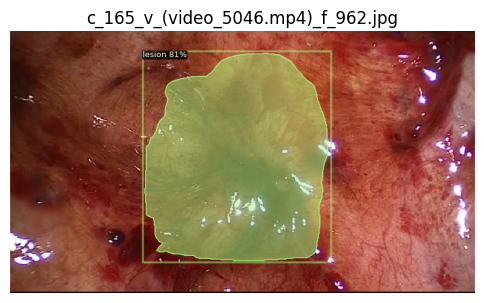

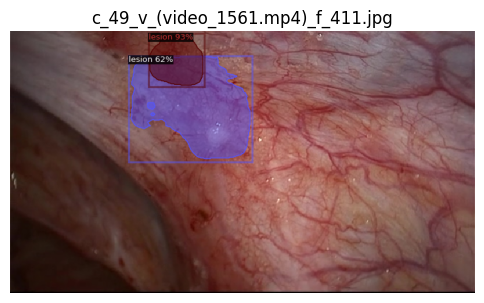

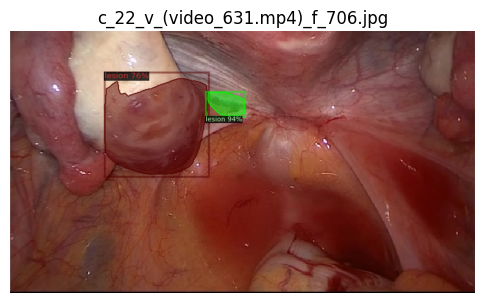

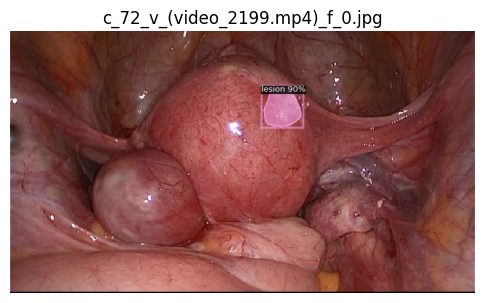

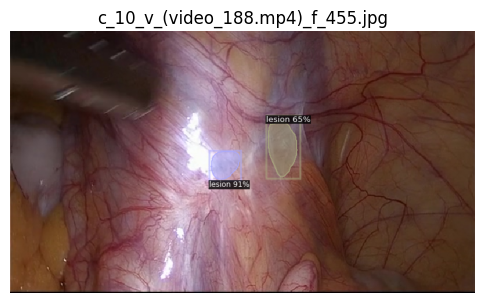

In [30]:
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog
test_dir = f"{base}/test/images"
test_imgs = os.listdir(test_dir)

for img_name in test_imgs[:5]:  # show first 5 predictions

    img_path = os.path.join(test_dir, img_name)
    img = cv2.imread(img_path)

    outputs = predictor(img)

    v = Visualizer(
        img[:, :, ::-1],
        MetadataCatalog.get("glenda_train"),
        scale=1.2
    )

    out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

    plt.figure(figsize=(6,6))
    plt.imshow(out.get_image())
    plt.title(img_name)
    plt.axis("off")
    plt.show()

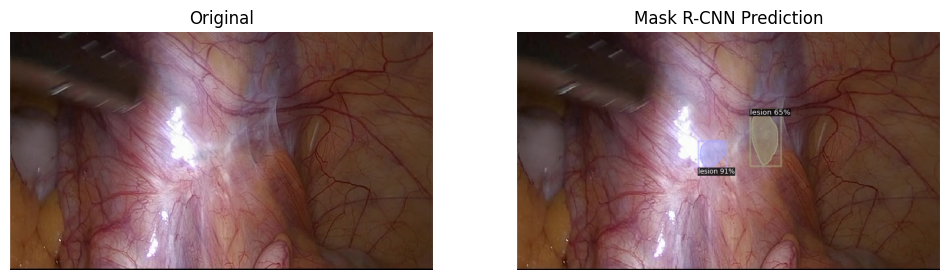

In [31]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(out.get_image())
plt.title("Mask R-CNN Prediction")
plt.axis("off")

plt.show()